In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
#import ipywidgets as widgets
import ipywidgets as widgets


In [43]:
def load(path):
    # Load
    df = pd.read_excel(path)
    col_checker = ['DATEPRD', 'BORE_OIL_VOL', 'WELL_BORE_CODE']
    #if any col_checkers in df.columns:
    for col in col_checker:
        if col in df.columns:
         #replace DATEPRD with TEST_DATE and BORE_OIL_VOL with OIL
            if col == 'DATEPRD':
                df.rename(columns={col: 'TEST_DATE'}, inplace=True)
                df['TEST_DATE'] = pd.to_datetime(df['TEST_DATE'])
            elif col == 'BORE_OIL_VOL':
                df.rename(columns={col: 'OIL'}, inplace=True)
            elif col=='WELL_BORE_CODE':
                df.rename(columns={col:'WELL_NAME'},inplace=True)
    if 'TEST_DATE' in df.columns:
        df['TEST_DATE'] = pd.to_datetime(df['TEST_DATE'], errors='coerce')
    if 'OIL' in df.columns:
        df['OIL'] = pd.to_numeric(df['OIL'], errors='coerce')
    return df

def prepare_oil_series(df, noise_window=3):
    # Keep valid rows, preserve temporal order, and smooth short-term noise.
    out = df.copy()
    out = out.dropna(subset=['TEST_DATE', 'OIL'])
    out = out.sort_values('TEST_DATE').reset_index(drop=True)
    out = out[out['OIL'] > 0].copy()
    out['OIL_CLEAN'] = out['OIL'].rolling(window=noise_window, min_periods=1).median()
    return out

def plot_data(data):
    plt.figure(figsize=(10, 6))
    plt.scatter(data['TEST_DATE'], data['OIL'], label='Oil', color='blue')
    plt.xlabel('Time (days)')
    plt.ylabel('Production (bbl/day)')
    plt.title(data['WELL_NAME'].iloc[0])
    plt.legend()
    plt.grid()
    plt.show()

In [37]:
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    # force 2D
    if isinstance(data, (list, np.ndarray)) and np.array(data).ndim == 1:
        data = np.array(data).reshape(-1, 1)

    df = pd.DataFrame(data)
    cols = []

    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
    for i in range(0, n_out):
        cols.append(df.shift(-i))

    agg = pd.concat(cols, axis=1)
    if dropnan:
        agg = agg.dropna()

    return agg.values

In [38]:
def train_test_split(data, n_test):
	return data[:-n_test, :], data[-n_test:, :]

In [46]:
def xgboost_forecast(train, testX):
	# transform list into array
	train = np.asarray(train)
	# split into input and output columns
	trainX, trainy = train[:, :-1], train[:, -1]
	# fit model
	model = XGBRegressor(
        objective='reg:squarederror',
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    )
	model.fit(trainX, trainy)
	# make a one-step prediction
	yhat = model.predict(np.asarray([testX]))
	return yhat[0]
 
# walk-forward validation for univariate data
def walk_forward_validation(data, n_test, verbose=False):
	predictions = list()
	# split dataset
	train, test = train_test_split(data, n_test)
	# seed history with training dataset
	history = [x for x in train]
	# step over each time-step in the test set
	for i in range(len(test)):
		# split test row into input and output columns
		testX, testy = test[i, :-1], test[i, -1]
		# fit model on history and make a prediction
		yhat = xgboost_forecast(history, testX)
		# store forecast in list of predictions
		predictions.append(yhat)
		# add actual observation to history for the next loop
		history.append(test[i])
		# summarize progress
		if verbose:
			print('>expected=%.1f, predicted=%.1f' % (testy, yhat))
	# estimate prediction error
	mae = mean_absolute_error(test[:, -1], predictions)
	r2 = r2_score(test[:, -1], predictions)
	return mae, r2, test[:, -1], np.asarray(predictions)

In [44]:
path='/home/rian/python_project/myvenv/dca_ml/data/Volve production data.xlsx'
data=load(path)
df=data[['TEST_DATE','OIL','WELL_NAME']]
well_name = "NO 15/9-F-12 H"
df = df[df['WELL_NAME'] == well_name]
#grab max min date value
min_date = df['TEST_DATE'].min()
max_date = df['TEST_DATE'].max()
#make a slider to select date range for OIL production data
date_range_slider = widgets.SelectionRangeSlider(
    options=[(date.strftime('%Y-%m-%d'), date) for date in pd.date_range(min_date, max_date)],
    index=(0, len(pd.date_range(min_date, max_date)) - 1),
    description='Date Range',
    orientation='horizontal',
    layout={'width': '500px'}
)

plot_output = widgets.Output()
table_output = widgets.Output()
slided_df = pd.DataFrame(columns=df.columns)

def get_slided_df():
    # Use this in other cells to work on a regular dataframe copy
    return slided_df.copy()

def update_plot(change):
    global slided_df
    start_date, end_date = change['new']
    slided_df = df[(df['TEST_DATE'] >= start_date) & (df['TEST_DATE'] <= end_date)].copy().reset_index(drop=True)

    with plot_output:
        plot_output.clear_output(wait=True)
        plot_data(slided_df)

    with table_output:
        table_output.clear_output(wait=True)
        display(slided_df)

date_range_slider.observe(update_plot, names='value')

# Render slider + reusable output areas
update_plot({'new': date_range_slider.value})
display(widgets.VBox([date_range_slider, plot_output, table_output]))

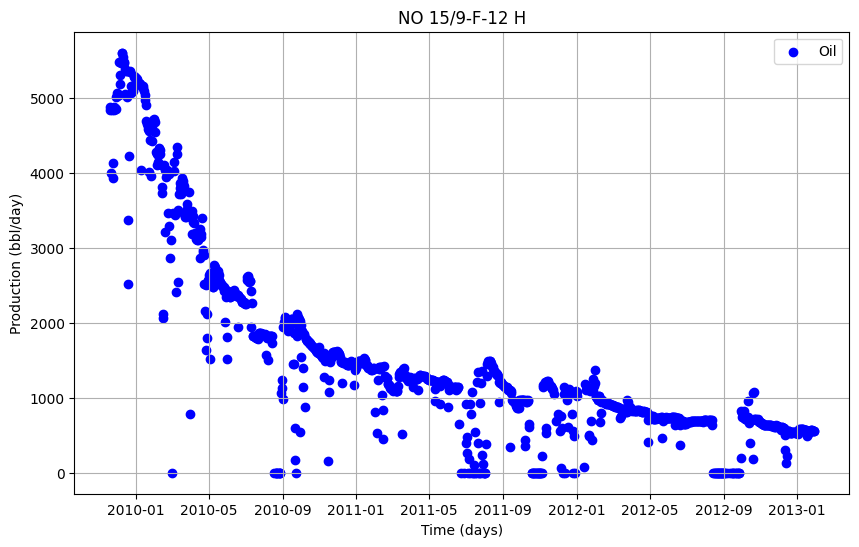

In [63]:
work_df = get_slided_df()
plot_data(work_df)

Train MAE: 37.67
Test MAE : 203.60
Test R2  : -5.687


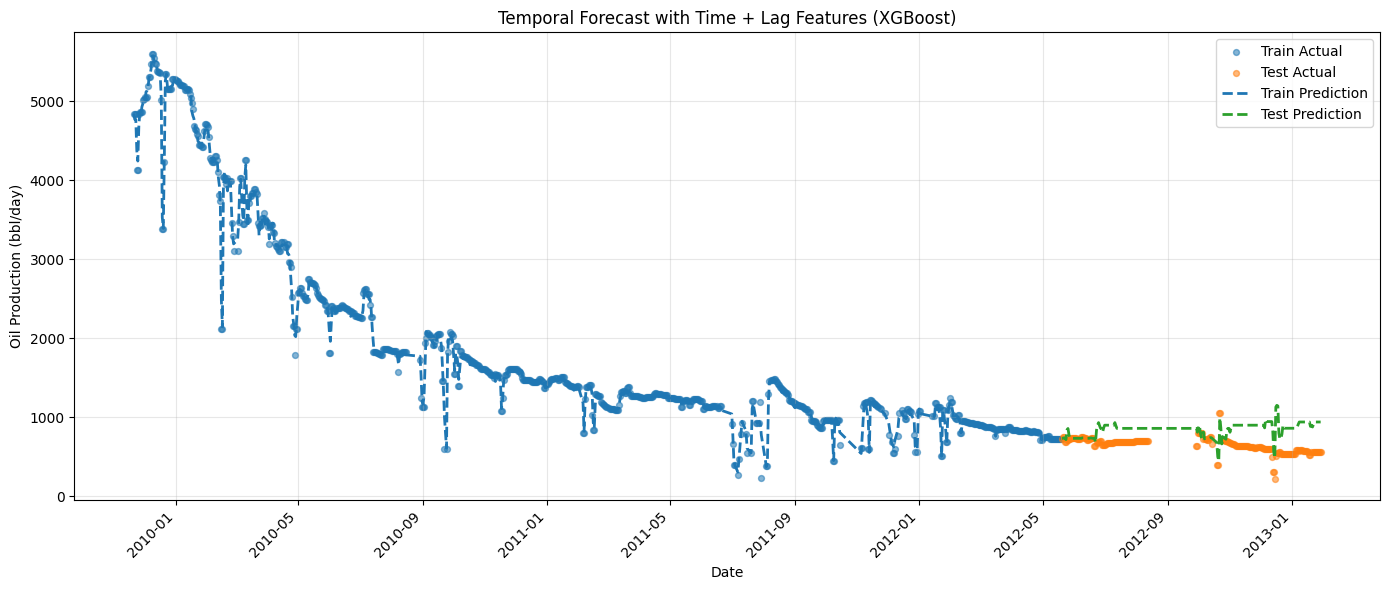

In [64]:
# Build temporally consistent features (time index + lagged production)
work_df = prepare_oil_series(work_df, noise_window=3)
model_df = work_df[['TEST_DATE', 'OIL_CLEAN']].copy()
model_df['t'] = (model_df['TEST_DATE'] - model_df['TEST_DATE'].min()).dt.days
model_df['lag_1'] = model_df['OIL_CLEAN'].shift(1)
model_df['lag_2'] = model_df['OIL_CLEAN'].shift(2)
model_df['lag_3'] = model_df['OIL_CLEAN'].shift(3)
model_df = model_df.dropna().reset_index(drop=True)

feature_cols = ['t', 'lag_1', 'lag_2', 'lag_3']
split = int(len(model_df) * 0.8)

train_df = model_df.iloc[:split]
test_df = model_df.iloc[split:]

X_train = train_df[feature_cols]
y_train = train_df['OIL_CLEAN']
X_test = test_df[feature_cols]
y_test = test_df['OIL_CLEAN']

model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=350,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Train MAE: {train_mae:.2f}")
print(f"Test MAE : {test_mae:.2f}")
print(f"Test R2  : {test_r2:.3f}")

# Plot full period as scatter + prediction lines for train and test
fig, ax = plt.subplots(figsize=(14, 6))

ax.scatter(train_df['TEST_DATE'], y_train, s=18, alpha=0.55, color='tab:blue', label='Train Actual')
ax.scatter(test_df['TEST_DATE'], y_test, s=18, alpha=0.55, color='tab:orange', label='Test Actual')

ax.plot(train_df['TEST_DATE'], y_train_pred, color='tab:blue', linestyle='--', linewidth=2, label='Train Prediction')
ax.plot(test_df['TEST_DATE'], y_test_pred, color='tab:green', linestyle='--', linewidth=2, label='Test Prediction')

ax.set_title('Temporal Forecast with Time + Lag Features (XGBoost)')
ax.set_xlabel('Date')
ax.set_ylabel('Oil Production (bbl/day)')
ax.grid(alpha=0.3)
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

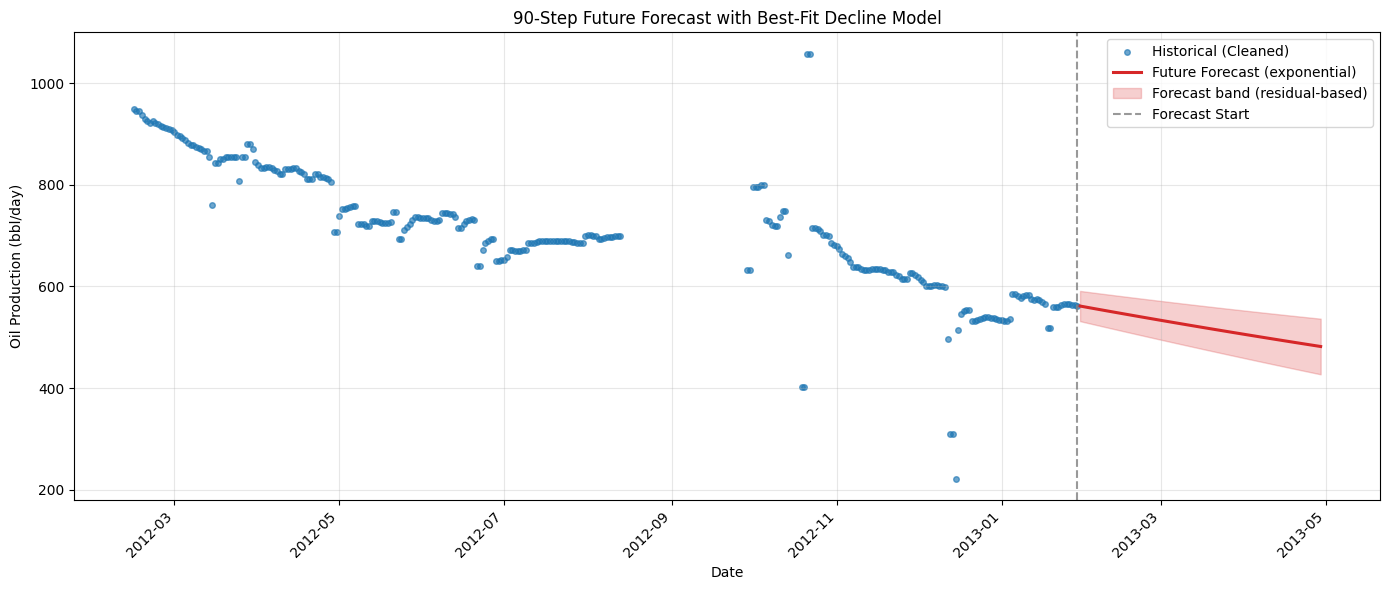

Best model by RMSE: exponential
Fit period: 2012-06-14 to 2013-01-29
         model       rmse
0  exponential  32.870326
1   hyperbolic  32.976317
2     harmonic  34.067592


,TEST_DATE,OIL_FORECAST_BASE,OIL_FORECAST_LOW,OIL_FORECAST_HIGH
0,2013-01-30,561.395107,531.662801,591.127412
1,2013-01-31,560.431869,530.419071,590.444668
2,2013-02-01,559.470285,529.176992,589.763577
3,2013-02-02,558.510350,527.936564,589.084135
4,2013-02-03,557.552062,526.697783,588.406341
5,2013-02-04,556.595418,525.460645,587.730191
6,2013-02-05,555.640416,524.225150,587.055682
7,2013-02-06,554.687052,522.991293,586.382812
8,2013-02-07,553.735324,521.759071,585.711577
9,2013-02-08,552.785229,520.528483,585.041976


In [65]:
# Multi-step future forecast with automatic best-fit decline model + uncertainty band
horizon = 90

# Time step
date_step_days = int(max(1, model_df['TEST_DATE'].diff().dropna().dt.days.median()))
last_date = model_df['TEST_DATE'].iloc[-1]
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=date_step_days),
    periods=horizon,
    freq=f'{date_step_days}D'
)

# Recent history used to fit decline models
trend_window = min(180, len(model_df))
recent = model_df.tail(trend_window).copy()
recent = recent[recent['OIL_CLEAN'] > 0].copy()

if len(recent) < 12:
    raise ValueError('Not enough positive recent points to fit decline models.')

# Robust outlier trimming for fitting only
q_low_cut, q_high_cut = recent['OIL_CLEAN'].quantile([0.05, 0.95])
recent_fit = recent[(recent['OIL_CLEAN'] >= q_low_cut) & (recent['OIL_CLEAN'] <= q_high_cut)].copy()
if len(recent_fit) < 12:
    recent_fit = recent.copy()

t_hist = np.arange(len(recent_fit), dtype=float)
q_hist = recent_fit['OIL_CLEAN'].values.astype(float)

# ---------- Model 1: Exponential ----------
# q(t) = qi * exp(-D t)
coef_exp = np.polyfit(t_hist, np.log(q_hist), 1)
D_exp = float(np.clip(-coef_exp[0], 1e-4, 0.1))
qi_exp = float(np.exp(coef_exp[1]))
q_fit_exp = qi_exp * np.exp(-D_exp * t_hist)
rmse_exp = float(np.sqrt(np.mean((q_hist - q_fit_exp) ** 2)))

# ---------- Model 2: Harmonic ----------
# q(t) = qi / (1 + D t)
inv_q = 1.0 / q_hist
coef_harm = np.polyfit(t_hist, inv_q, 1)
A_h = max(float(coef_harm[1]), 1e-10)
B_h = max(float(coef_harm[0]), 0.0)
qi_harm = 1.0 / A_h
D_harm = B_h / A_h
q_fit_harm = qi_harm / (1.0 + D_harm * t_hist)
rmse_harm = float(np.sqrt(np.mean((q_hist - q_fit_harm) ** 2)))

# ---------- Model 3: Hyperbolic ----------
# q(t) = qi / (1 + b D t)^(1/b)
b_grid = np.arange(0.1, 1.55, 0.05)
best_hyp = None

for b in b_grid:
    y = q_hist ** (-b)
    coef = np.polyfit(t_hist, y, 1)
    A = float(coef[1])
    B = float(coef[0])
    if A <= 0 or B < 0:
        continue

    qi = A ** (-1.0 / b)
    D = B / (b * A)
    q_fit = qi / ((1.0 + b * D * t_hist) ** (1.0 / b))
    rmse = float(np.sqrt(np.mean((q_hist - q_fit) ** 2)))

    if (best_hyp is None) or (rmse < best_hyp['rmse']):
        best_hyp = {
            'b': float(b),
            'qi': float(qi),
            'D': float(np.clip(D, 1e-4, 0.1)),
            'rmse': rmse,
            'q_fit': q_fit
        }

if best_hyp is None:
    raise ValueError('Hyperbolic fit failed for all b values.')

rmse_hyp = best_hyp['rmse']

# Pick best model by RMSE
fit_table = pd.DataFrame([
    {'model': 'exponential', 'rmse': rmse_exp},
    {'model': 'harmonic', 'rmse': rmse_harm},
    {'model': 'hyperbolic', 'rmse': rmse_hyp},
]).sort_values('rmse').reset_index(drop=True)

best_model = fit_table.loc[0, 'model']
rmse_best = float(fit_table.loc[0, 'rmse'])

# Start forecast from last observed cleaned rate for continuity
q0 = float(model_df['OIL_CLEAN'].iloc[-1])
t_future = np.arange(1, horizon + 1, dtype=float) * date_step_days

if best_model == 'exponential':
    D = D_exp
    q_base = q0 * np.exp(-D * t_future)
elif best_model == 'harmonic':
    D = D_harm
    q_base = q0 / (1.0 + D * t_future)
else:
    b = best_hyp['b']
    D = best_hyp['D']
    q_base = q0 / ((1.0 + b * D * t_future) ** (1.0 / b))

q_base = np.maximum(q_base, 0.0)

# Residual-based prediction interval (wider and more informative)
# 1.28 ~ 80% normal interval; widen slightly with horizon
z = 1.28
h_scale = 0.7 + 0.6 * (np.arange(1, horizon + 1) / horizon)
interval = z * rmse_best * h_scale
q_low = np.maximum(q_base - interval, 0.0)
q_high = q_base + interval

future_forecast_df = pd.DataFrame({
    'TEST_DATE': future_dates,
    'OIL_FORECAST_BASE': q_base,
    'OIL_FORECAST_LOW': q_low,
    'OIL_FORECAST_HIGH': q_high,
})

# Plot history + base forecast + confidence band
plot_window = 300
history_plot_df = model_df.tail(plot_window)

fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(
    history_plot_df['TEST_DATE'],
    history_plot_df['OIL_CLEAN'],
    s=16,
    alpha=0.65,
    color='tab:blue',
    label='Historical (Cleaned)'
)

ax.plot(
    future_forecast_df['TEST_DATE'],
    future_forecast_df['OIL_FORECAST_BASE'],
    color='tab:red',
    linewidth=2.2,
    label=f'Future Forecast ({best_model})'
)

ax.fill_between(
    future_forecast_df['TEST_DATE'],
    future_forecast_df['OIL_FORECAST_LOW'],
    future_forecast_df['OIL_FORECAST_HIGH'],
    color='tab:red',
    alpha=0.22,
    label='Forecast band (residual-based)'
)

ax.axvline(last_date, color='gray', linestyle='--', alpha=0.8, label='Forecast Start')
ax.set_title(f'{horizon}-Step Future Forecast with Best-Fit Decline Model')
ax.set_xlabel('Date')
ax.set_ylabel('Oil Production (bbl/day)')
ax.grid(alpha=0.3)
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Best model by RMSE:', best_model)
print('Fit period:', recent_fit['TEST_DATE'].iloc[0].date(), 'to', recent_fit['TEST_DATE'].iloc[-1].date())
print(fit_table)
future_forecast_df.head(10)